In [264]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [265]:
names = open('data/names.txt', 'r').read().splitlines()
names[:5]

['rosaline', 'jami-pekka', 'meemi', 'sävele', 'mawada']

In [266]:
vocabulary = ['<S>', '<E>', '<PAD>'] + sorted(list(set(''.join(names))))
len(vocabulary)

55

In [267]:
atoi = {c: i for i, c in enumerate(vocabulary)}
itoa = {i: c for i, c in enumerate(vocabulary)}

In [268]:
def prepare_name(name):
    return [0] + [atoi[ch] for ch in name.lower()] + [1]

def build_dataset(words):  
  X, Y = [], []

  sequences = [prepare_name(name) for name in words]
  max_len = max(len(seq) for seq in sequences)

  for seq in sequences:
      x = seq[:-1] + [2] * (max_len - len(seq))
      y = seq[1:] + [2] * (max_len - len(seq))
      X.append(x)
      Y.append(y)

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  
  print(X.shape, Y.shape)

  return X, Y

n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

X, y = build_dataset(names)

Xtr,  Ytr  = X[:n1], y[:n1]         # 80%
Xdev, Ydev = X[n1:n2], y[n1:n2]     # 10%
Xte,  Yte  = X[n2:], y[n2:]         # 10%

torch.Size([23184, 17]) torch.Size([23184, 17])


In [269]:
for x,y in zip(Xtr[:10], Ytr[:10]):
    print(''.join(itoa[int(ix.item())] for ix in x), '-->', ''.join(itoa[int(y.item())] for y in y))

<S>rosaline<PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD> --> rosaline<E><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD>
<S>jami-pekka<PAD><PAD><PAD><PAD><PAD><PAD> --> jami-pekka<E><PAD><PAD><PAD><PAD><PAD><PAD>
<S>meemi<PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD> --> meemi<E><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD>
<S>sävele<PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD> --> sävele<E><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD>
<S>mawada<PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD> --> mawada<E><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD>
<S>eila-riitta<PAD><PAD><PAD><PAD><PAD> --> eila-riitta<E><PAD><PAD><PAD><PAD><PAD>
<S>miyuki<PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD> --> miyuki<E><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD>
<S>veli-petteri<PAD><PAD><PAD><PAD> --> veli-petteri<E><PAD><PAD><PAD><PAD>
<S>olive<PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD> --> olive<E><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD>
<S>m

In [270]:
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, nheads, context_len):
        super().__init__()

        assert embed_dim % nheads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = nheads
        self.head_dim = embed_dim // nheads

        causal_mask = torch.tril(torch.ones(context_len, context_len))
        self.register_buffer('causal_mask', causal_mask)

        self.q = nn.Linear(self.embed_dim, self.embed_dim, bias=False)
        self.k = nn.Linear(self.embed_dim, self.embed_dim, bias=False)
        self.v = nn.Linear(self.embed_dim, self.embed_dim, bias=False)
        self.wo = nn.Linear(self.embed_dim, self.embed_dim, bias=False)

        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        batch_size, seq_len, embed_dim = x.shape

        # (batch, seq_len, embed_dim)
        q: torch.Tensor = self.q(x)
        k: torch.Tensor = self.k(x)
        v: torch.Tensor = self.v(x)

        q = q.view(batch_size, seq_len, self.num_heads, self.head_dim)
        k = k.view(batch_size, seq_len, self.num_heads, self.head_dim)
        v = v.view(batch_size, seq_len, self.num_heads, self.head_dim)

        # (batch, num_heads, seq_len, head_dim)
        q = q.transpose(1, 2)  
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        # (batch, num_heads, seq_len, seq_len)
        qk: torch.Tensor = q @ k.transpose(-2, -1) / (self.embed_dim ** 0.5)

        masked = qk.masked_fill(self.causal_mask == 0, float('-inf'))

        weights = F.softmax(masked, dim=-1)
        weights = self.dropout(weights)
        out = weights @ v

        # (batch, seq_len, num_heads, head_dim)
        out = out.transpose(1, 2).contiguous()
        out = out.view(batch_size, seq_len, self.embed_dim)

        out = self.wo(out)
        
        return out, weights

class FeedFoward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(0.2),
        )

    def forward(self, x):
        return self.net(x)
    
class Block(nn.Module):
    def __init__(self, embed_dim, nheads, context_len):
        super().__init__()

        self.attention = MultiHeadAttention(embed_dim, nheads, context_len)
        self.ffwd = FeedFoward(embed_dim)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.norm1(x)
        attn_out, _ = self.attention(x)
        x = x + self.ffwd(self.norm2(attn_out))
        return x

class PositionalEncoding(nn.Module):

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Arguments:
            x: Tensor, shape ``[seq_len, batch_size, embedding_dim]``
        """
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

class Transformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, nheads, context):
        super().__init__()

        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.nheads = nheads

        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim, dropout=0.1, max_len=context)

        self.attentions = nn.Sequential(*[
            Block(embed_dim, nheads=self.nheads, context_len=context),
            Block(embed_dim, nheads=self.nheads, context_len=context),
        ])
        self.ln_f = nn.LayerNorm(embed_dim)
        self.fc = nn.Linear(embed_dim, vocab_size)

        
    def forward(self, x):
        x = self.token_embedding(x) * math.sqrt(self.embed_dim)
        pe = self.positional_encoding(x.transpose(0, 1)).transpose(0, 1)
        x = x + pe

        x = self.attentions(x)
        x = self.ln_f(x)
        
        logits = self.fc(x)

        return logits

In [271]:
CONTEXT = len(Xtr[1])
EMBED_DIM = 128
NHEADS = 8
BATCH_SIZE = 64
EPOCHS = 30_000
LR = 1e-4

vocab_size = len(vocabulary)

print(f"Vocabulary size: {vocab_size}")
print(f"Training samples: {len(Xtr)}")

model = Transformer(vocab_size, embed_dim=EMBED_DIM, nheads=NHEADS, context=CONTEXT)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

num_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {num_params:,}")

losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()

    idx = torch.randint(0, len(Xtr), (BATCH_SIZE,))
    xb, yb = Xtr[idx], Ytr[idx]

    logits = model(xb)

    loss = F.cross_entropy(logits.view(-1, vocab_size), yb.view(-1), ignore_index=2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 1000 == 0:
        with torch.no_grad():
            model.eval()

            dev_logits = model(Xdev)
            dev_loss = F.cross_entropy(
                dev_logits.view(-1, vocab_size), Ydev.view(-1), ignore_index=2
            )
            val_losses.append(dev_loss.item())

        recent_training_loss = sum(losses[-1000:]) / 1000

        print(
            f"Epoch {epoch:4d} | loss {recent_training_loss:.4f} | dev loss {dev_loss.item():.4f}"
        )

Vocabulary size: 55
Training samples: 18547
Parameters: 409,911
Epoch 1000 | loss 2.5368 | dev loss 2.2814
Epoch 2000 | loss 2.2851 | dev loss 2.1904
Epoch 3000 | loss 2.2144 | dev loss 2.1347
Epoch 4000 | loss 2.1668 | dev loss 2.0937
Epoch 5000 | loss 2.1257 | dev loss 2.0676
Epoch 6000 | loss 2.0993 | dev loss 2.0384
Epoch 7000 | loss 2.0686 | dev loss 2.0195
Epoch 8000 | loss 2.0481 | dev loss 2.0076
Epoch 9000 | loss 2.0301 | dev loss 1.9915
Epoch 10000 | loss 2.0149 | dev loss 1.9843
Epoch 11000 | loss 1.9986 | dev loss 1.9751
Epoch 12000 | loss 1.9868 | dev loss 1.9652
Epoch 13000 | loss 1.9765 | dev loss 1.9593
Epoch 14000 | loss 1.9672 | dev loss 1.9506
Epoch 15000 | loss 1.9585 | dev loss 1.9503
Epoch 16000 | loss 1.9521 | dev loss 1.9438
Epoch 17000 | loss 1.9385 | dev loss 1.9443
Epoch 18000 | loss 1.9327 | dev loss 1.9356
Epoch 19000 | loss 1.9258 | dev loss 1.9361
Epoch 20000 | loss 1.9168 | dev loss 1.9292
Epoch 21000 | loss 1.9108 | dev loss 1.9239
Epoch 22000 | loss 1.

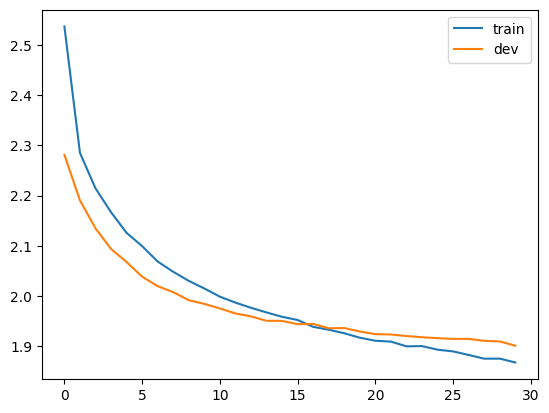

In [275]:
plt.plot(torch.tensor(losses).view(-1, 1000).mean(dim=1))
plt.plot(torch.tensor(val_losses))
plt.legend(['train', 'dev'])

In [276]:
@torch.no_grad()
def generate(model, start_prompt, max_length=20, temperature=0.8):
    model.eval()

    generated = start_prompt

    start_pos = 1 if len(start_prompt) == 0 else len(start_prompt)

    for i in range(start_pos, max_length):
        input_seq = [0] + [atoi[ch] for ch in generated]
        input_seq += [0] * (max_length - len(input_seq))
        input_seq = input_seq[-max_length:]
        input_tensor = torch.tensor([input_seq], dtype=torch.long)

        logits = model(input_tensor) / temperature
        probs = F.softmax(logits[:, i, :], dim=-1)
        next_token_id = torch.multinomial(probs, num_samples=1).item()

        if next_token_id == 1:
            break

        generated += itoa[int(next_token_id)]

    return generated

In [283]:
for i in range(10):
    n = generate(model, start_prompt='m', max_length=CONTEXT, temperature=0.8)
    print(n)

maija-elina
matti-pekka
mija-liisa
marielia
matili
maria
midica
mila-maria
maarkhina
marjutta
